La fuente utilizada es: https://www.kaggle.com/datasets/algozee/smartphone-addiction-prediction-data para nuestra base de datos que vamos a utilizar

Mineria de Datos


---


Unidad 1

Sección: 001D

Integrantes:

*   José Muñoz
*   Paolo Sala



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.ensemble
import sklearn.model_selection


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Smartphone_Usage_Addiction.csv")


print(f"Filas cargadas: {len(df)}")

Filas cargadas: 7500


In [ ]:
df.head(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


In [ ]:
df.tail(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
7490,TXN07491,U07491,21,Female,3.08,5.68,3.57,5.53,4.89,41,104,5.82,High,No,Severe,1
7491,TXN07492,U07492,29,Male,6.42,4.21,0.38,3.86,6.37,40,28,8.12,Medium,No,Severe,1
7492,TXN07493,U07493,27,Female,3.29,1.82,0.41,5.94,6.86,29,117,4.03,High,No,Mild,0
7493,TXN07494,U07494,19,Female,10.41,3.32,3.88,5.58,6.77,122,96,10.93,Low,Yes,Severe,1
7494,TXN07495,U07495,23,Other,6.65,4.56,1.31,5.09,5.71,78,77,7.43,Medium,No,Severe,1
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1
7499,TXN07500,U07500,27,Female,10.04,5.40,0.73,5.45,5.58,215,38,12.17,Low,Yes,Severe,1


In [ ]:
df.shape  # realizamos un shape para ver la cantidad de flias y como podemos ver las filas cuenta con un 7500 y las columnas se nos muestan 16 en cantidad

(7500, 16)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
transaction_id,object
user_id,object
age,int64
gender,object
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,int64


In [ ]:
#Transaction_Id: ID de la transaccion.
#User_ID: ID de usuario
#Age: Edad
#Gender: El sexo
#Daily_screentime_hours: Horas diarias de tiempo con pantallas
#Social_Media_Hours: Horas en redes sociales.
#Gaming_Hours: Horas utilizadas en juegos
#Work_study_hours: Horas utilizadas en trabajo o en estudios
#Sleep_Hours: Horas que uno tiene para dormir.
#Notifications_per_day: Notificaciones recibidas por dia.
#App_opens_per_day: Cuantas veces una aplicación se abre.
#Weekend_Screen_time: Cuanto tiempo se utiliza en el fin de semana.
#Stress_Level: Cuanto Stress le genera hacia el usuario.
#Academic_work_impact: Cuanto afecta el trabajo o el area de estudios
#Addiction_level: Nivel de addicción.
#Addicted_label: Confirmar si esta adicto a los telefonos o no.

In [ ]:
df.describe().round()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0,7500.0
mean,27.0,7.0,3.0,2.0,3.0,7.0,134.0,98.0,9.0,1.0
std,5.0,3.0,2.0,1.0,2.0,1.0,67.0,48.0,3.0,0.0
min,18.0,3.0,0.0,0.0,0.0,4.0,20.0,15.0,4.0,0.0
25%,22.0,5.0,2.0,1.0,2.0,6.0,76.0,55.0,7.0,0.0
50%,27.0,8.0,3.0,2.0,3.0,7.0,134.0,98.0,9.0,1.0
75%,31.0,10.0,5.0,3.0,5.0,8.0,191.0,140.0,12.0,1.0
max,35.0,12.0,6.0,4.0,6.0,9.0,250.0,180.0,15.0,1.0


In [ ]:
df_columnas = df.columns
print( df_columnas)

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')


In [ ]:
# identificar

df.isna().sum()

#devuelve la columnas la cantidad de filas nulos

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


La razón porque hay un monton de nulos en el nivel de addicción es debido a que esas personas no estaban consideradas addictas, debido a que si el label de addicción equivale a 1 ellos estaban clasificados para el nivel de addicción. De lo contrario, si esta en 0? no se clasifica y queda como un nulo.

In [ ]:
df['addiction_level'] = df['addiction_level'].fillna('Low')

In [ ]:
df.head(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Low,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Low,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,Low,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


Veremos otra tecnica de imputacion de nulos en la segunda unidad.

# **Clasificacion de Variables**

In [ ]:
can_tsocial_media_hours = df['social_media_hours'].value_counts()
print(can_tsocial_media_hours)

print(f"Cantidad de boroughs distintos: {can_tsocial_media_hours.count()}")

social_media_hours
0.99    24
3.07    24
3.00    23
5.03    23
3.54    23
        ..
0.50     6
3.79     5
5.56     5
5.36     5
3.31     4
Name: count, Length: 551, dtype: int64
Cantidad de boroughs distintos: 551


Interpretación del Resultado

La tabla que ves muestra dos columnas principales:

* Columna Izquierda (social_media_hours): Representa la cantidad exacta de horas reportadas por los usuarios.

* Columna Derecha: Representa la frecuencia, es decir, cuántas personas registraron ese tiempo exacto.

Ejemplo de los primeros datos:

    Hay 24 personas que pasan exactamente 0.99 horas en redes sociales.

    Hay 24 personas que pasan exactamente 3.07 horas.

    Hay 23 personas que pasan exactamente 3.00 horas.

3. Observaciones Clave

 * Diversidad de datos: El sistema indica que hay 551 valores distintos (Length: 551). Esto significa que  la  muestra de 7,500 personas, existen 551 variaciones diferentes de tiempo dedicado a redes sociales.

Este análisis te sirve para confirmar que tus datos numéricos son muy variados (continuos) y no están agrupados en solo 3 o 4 categorías.

In [ ]:
can_stress_level = df['stress_level'].value_counts()
print(can_stress_level)

print(f"Cantidad  de tipo de estres  distintos: {can_stress_level.count()}")

stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64
Cantidad  de tipo de estres  distintos: 3


In [ ]:


print("--- Distribución por Género ---")
print(df['gender'].value_counts())
print(f"Total de categorías: {df['gender'].nunique()}\n")

print("--- Niveles de Estrés reportados ---")
print(df['stress_level'].value_counts())

print("\n--- ¿Afecta el smartphone al rendimiento académico? ---")
print(df['academic_work_impact'].value_counts())

--- Distribución por Género ---
gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64
Total de categorías: 3

--- Niveles de Estrés reportados ---
stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64

--- ¿Afecta el smartphone al rendimiento académico? ---
academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64


# Interpretacion del resultado :

1. **Distribucion por genero:**



*   **Resultado:** Male(2553), Other(2486), Female(2461).

* **Interpretacion**: la muestra de 7.500 personas esta  equilibrado, no hay un predominio masivo de un solo genero, lo que significa que los resultados de prediccion no estarán sesgados o inclinados injustamente hacia un grupo especifico


2. Niveles de Estrés Reportados

* **Resultado**: High (2560), Low (2503), Medium (2437).

* **Interpretación**: Al igual que el género, los niveles de estrés están repartidos de forma casi uniforme. Es interesante notar que el nivel "High" (Alto) es el más frecuente. Esto te servirá más adelante para ver si existe una correlación entre el estrés alto y el uso excesivo del teléfono.

3. Impacto en el Rendimiento Académico

* **Resultado:** No (3753), Yes (3747).

 * **Interpretación:** Esta es una de las variables más importantes. por que  La muestra está dividida casi exactamente a la mitad (solo hay 6 votos de diferencia). Esto indica que la percepción sobre si el smartphone afecta los estudios es un tema muy debatido entre los encuestados y será un factor clave para clasificar la adicción.





# **Graficos**

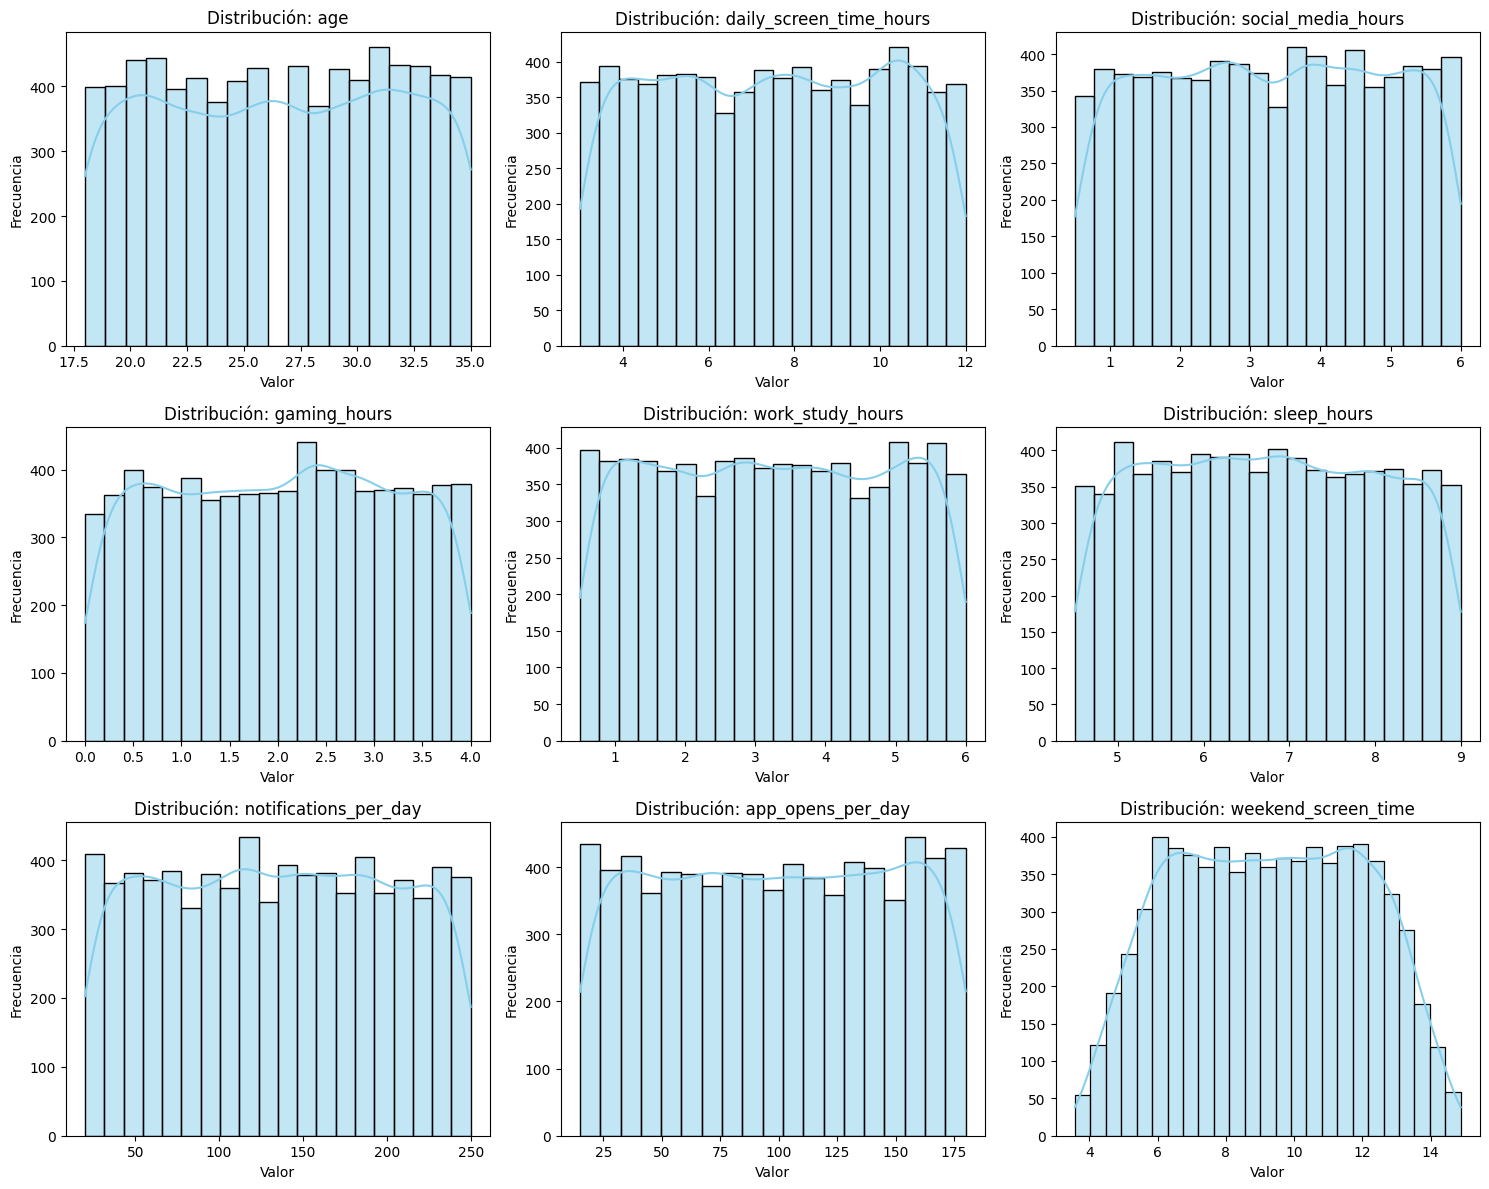

In [ ]:




cols_numericas = [
    'age', 'daily_screen_time_hours', 'social_media_hours',
    'gaming_hours', 'work_study_hours', 'sleep_hours',
    'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución: {col}', fontsize=12)
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

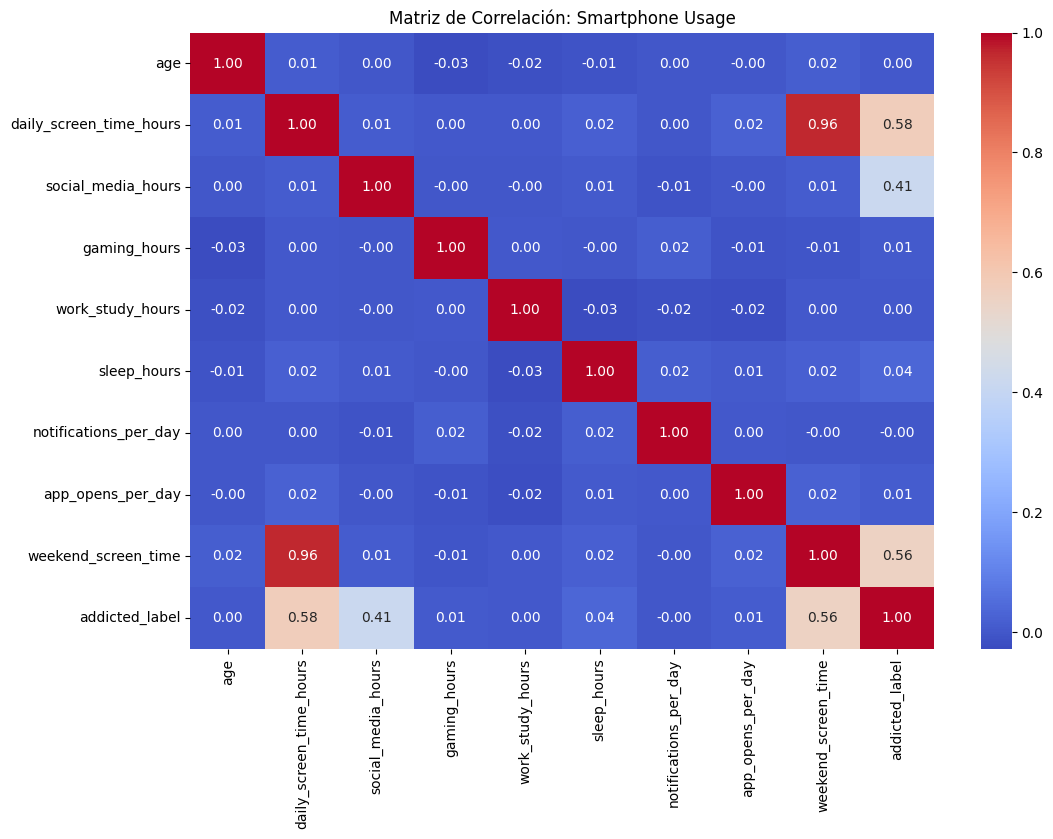

In [ ]:


plt.figure(figsize=(12, 8))
corr = df[cols_numericas + ['addicted_label']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Smartphone Usage')
plt.show()



1. Daily_screen_time_hours - weekend_screen_time = 0.96: en este resultado se muestra que mayoritariamente las personas se ponen a utilizar sus telefonos durante los fines de semana más que en los otros días de la semana.

2. Daily_screen_time_hours - addicted_label = 0.58: en este resultado se nos muestra  que en los tiempos en pantallas por hora estan relacionados con las personas que estan en moderate o severe es decir que solo se contabiliza a las personas que tienen rango alto de addicción.


3. addicted_label - weekend_screen_time = 0.56: se muestra que por lo menos la mitad de las personas estan en el rango de ser addicto debido a que sus horas aumentan exponencialmente en el fin de semana.


4. addicted_label - social_media_hours = 0.41: se muestra que menos de la mitad de las personas que estan addictas utilizan redes sociales. Mientras que el resto o que las utiliza pero no estan addictas en el primer lugar.